In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval, LinearStretch, ImageNormalize
from lsst.daf.butler import Butler, Timespan

butler = Butler("dp1", collections="LSSTComCam/DP1")
ra, dec, band = 53.076, -28.110, "r"
ts = Timespan(None, None)

def show(img, title):
    fig, ax = plt.subplots(figsize=(5, 5))
    norm = ImageNormalize(img.array, interval=ZScaleInterval(), stretch=LinearStretch())
    ax.imshow(img.array, origin="lower", cmap="gray", norm=norm)
    ax.set_title(title)
    plt.show()

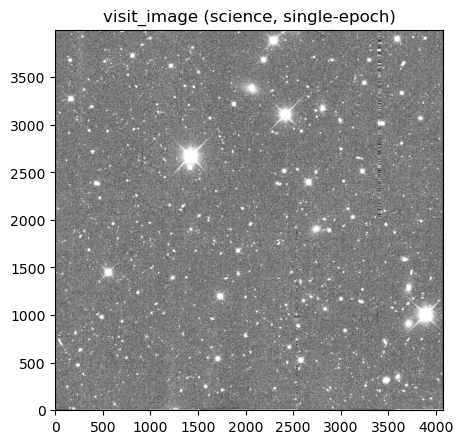

In [2]:
refs = butler.query_datasets("visit_image",
    where="band.name = :band AND visit.timespan OVERLAPS :timespan AND visit_detector_region.region OVERLAPS POINT(:ra, :dec)",
    bind={"band": band, "timespan": ts, "ra": ra, "dec": dec})
visit_image = butler.get(refs[0])
show(visit_image.image, "visit_image (science, single-epoch)")

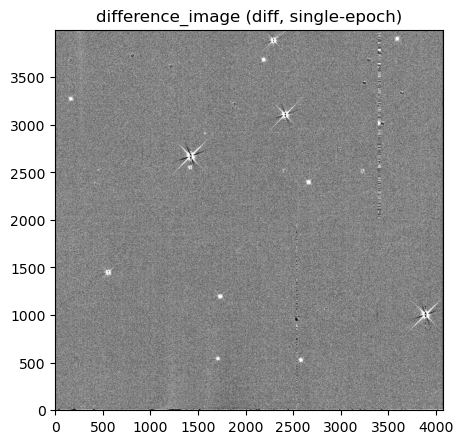

In [3]:
refs = butler.query_datasets("difference_image",
    where="band.name = :band AND visit.timespan OVERLAPS :timespan AND visit_detector_region.region OVERLAPS POINT(:ra, :dec)",
    bind={"band": band, "timespan": ts, "ra": ra, "dec": dec})
difference_image = butler.get(refs[0])
show(difference_image.image, "difference_image (diff, single-epoch)")

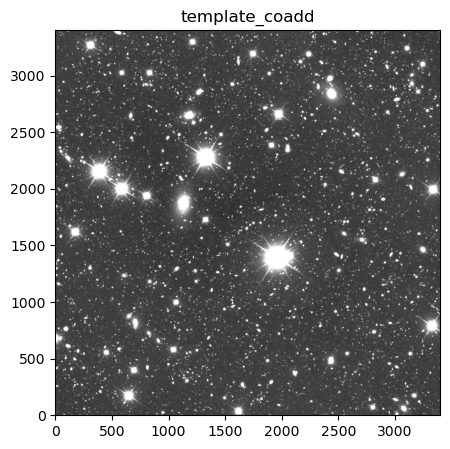

In [4]:
refs = butler.query_datasets("template_coadd", where=f"band.name = '{band}' AND patch.region OVERLAPS POINT({ra}, {dec})")
template_coadd = butler.get(refs[0])
show(template_coadd.image, "template_coadd")

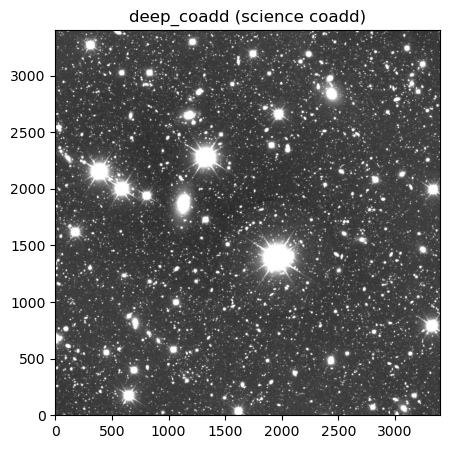

In [5]:
refs = butler.query_datasets("deep_coadd", where=f"band.name = '{band}' AND patch.region OVERLAPS POINT({ra}, {dec})")
deep_coadd = butler.get(refs[0])
show(deep_coadd.image, "deep_coadd (science coadd)")

No `diff_coadd`/`difference_coadd` dataset type exists in DP1 or DP2 -- no `assembleDiffCoadd`-type task in the pipeline, coadds are only built from direct/science images.